# Cap. 03 — Introducción a los Algoritmos Cuánticos
## Listing 3-8: Algoritmo de Deutsch-Jozsa (Cirq)

**Referencia:** Pattanayak, *Quantum Machine Learning with Python*, Capítulo 3, Listing 3-8.

### Problema que resuelve

Dado un oráculo que implementa una función $f: \{0,1\}^n \rightarrow \{0,1\}$, determinar si $f$ es:
- **Constante:** devuelve siempre 0 o siempre 1 para cualquier entrada
- **Balanceada:** devuelve 0 exactamente para la mitad de las entradas y 1 para la otra mitad

Clásicamente se necesitan hasta $2^{n-1} + 1$ consultas al oráculo en el peor caso.  
Deutsch-Jozsa lo resuelve con **una sola consulta** al oráculo cuántico.

### Pasos del algoritmo

| Paso | Acción | Estado resultante |
|---|---|---|
| 0 | Inicializar $n$ qubits de entrada + 1 qubit objetivo | $\vert 0\rangle^{\otimes n}\vert 0\rangle$ |
| 1 | H en cada qubit de entrada → superposición uniforme | $\frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n-1} \vert x\rangle \vert 0\rangle$ |
| 2 | X + H en qubit objetivo → estado $\vert -\rangle$ | $\frac{1}{\sqrt{2^n}} \sum_x \vert x\rangle \vert -\rangle$ |
| 3 | Oracle $U_f$ → **phase kickback**: la fase $(-1)^{f(x)}$ pasa a los qubits de entrada | $\frac{1}{\sqrt{2^n}} \sum_x (-1)^{f(x)} \vert x\rangle \vert -\rangle$ |
| 4 | H en cada qubit de entrada → interferencia | $\sum_z \left(\sum_x (-1)^{f(x)+x\cdot z}\right) \vert z\rangle$ |
| 5 | Medir qubits de entrada | Si $f$ es **constante** → siempre $\vert 00\rangle$; si es **balanceada** → nunca $\vert 00\rangle$ |

### Truco del phase kickback

Cuando el qubit objetivo está en el estado $\vert -\rangle = \frac{1}{\sqrt{2}}(\vert 0\rangle - \vert 1\rangle)$, aplicar el oráculo $U_f$ sobre él tiene el efecto de multiplicar el estado de los qubits de entrada por la fase $(-1)^{f(x)}$:

$$U_f\,\vert x\rangle\vert -\rangle = (-1)^{f(x)}\vert x\rangle\vert -\rangle$$

Así, la información de $f$ queda codificada en la **fase** de los qubits de entrada, no en el qubit objetivo.

### Implementación: domain_size = 4 → 2 qubits de entrada + 1 objetivo

**Función balanceada implementada:** $f(x_0, x_1) = x_0 \oplus x_1$ (XOR):

| Estado | $f(x)$ |
|:---:|:---:|
| $\vert 00\rangle$ | 0 |
| $\vert 01\rangle$ | 1 |
| $\vert 10\rangle$ | 1 |
| $\vert 11\rangle$ | 0 |

El oráculo para esta función aplica CNOT(data[0] → y) y CNOT(data[1] → y), lo que implementa $y \oplus x_0 \oplus x_1$.  
**Función constante implementada:** $f(x) = 0$ → oráculo = identidad (no se aplica ninguna puerta).

### Oráculo

El oráculo es el componente central del algoritmo: representa la función $f$ desconocida como una caja negra. Deutsch-Jozsa determina si es balanceada o constante sin "mirar dentro" del oráculo — solo consultándolo una vez.

In [1]:
import cirq
import numpy as np


def oracle(data_reg, y_reg, circuit, is_balanced=True):
    """
    Aplica el oráculo U_f al circuito.

    Función balanceada f(x0, x1) = x0 XOR x1:
      - CNOT(data[0] → y): y ← y XOR x0
      - CNOT(data[1] → y): y ← y XOR x0 XOR x1
      Resultado neto: y XOR f(x), que implementa el phase kickback.

    Función constante f(x) = 0:
      - Identidad: no se aplica ninguna puerta.
      - El qubit objetivo y_reg queda inalterado (en estado |-⟩).
    """
    if is_balanced:
        # Implementa f(x0, x1) = x0 ⊕ x1 mediante dos CNOT sucesivos
        circuit.append([
            cirq.CNOT(data_reg[0], y_reg),  # y ← y XOR x0
            cirq.CNOT(data_reg[1], y_reg),  # y ← y XOR x0 XOR x1
        ])
    # Si is_balanced=False: oráculo = identidad → f(x) = 0 constante
    return circuit

### Algoritmo principal

La función retorna el circuito y el resultado de la simulación para poder visualizarlos por separado en el notebook.

In [2]:
def deutsch_jozsa(domain_size: int,
                  func_type_to_simulate: str = 'balanced',
                  copies: int = 1000):
    """
    Implementa el algoritmo de Deutsch-Jozsa.

    domain_size:            número de entradas de la función (debe ser potencia de 2)
    func_type_to_simulate:  'balanced' para función balanceada, cualquier otro valor para constante
    copies:                 repeticiones de la simulación

    Retorna: (circuit, result)
    """
    # Número de qubits de entrada: n = log2(domain_size)
    # Para domain_size=4 → n=2 qubits de entrada + 1 qubit objetivo
    n = int(np.ceil(np.log2(domain_size)))

    # Registro de qubits de entrada (Alice / consulta)
    data_reg = [cirq.LineQubit(i) for i in range(n)]

    # Qubit objetivo (target / ancilla), inicializado en |0⟩
    y_reg = cirq.LineQubit(n)

    circuit = cirq.Circuit()

    # Paso 1: H en cada qubit de entrada → superposición uniforme |+⟩^⊗n
    circuit.append(cirq.H(data_reg[i]) for i in range(n))

    # Paso 2: preparar qubit objetivo en |-⟩ = H|1⟩
    # X transforma |0⟩ → |1⟩, luego H transforma |1⟩ → |-⟩
    circuit.append(cirq.X(y_reg))
    circuit.append(cirq.H(y_reg))

    # Paso 3: consulta al oráculo U_f
    # El phase kickback codifica (-1)^f(x) en la fase de los qubits de entrada
    is_balanced = (func_type_to_simulate == 'balanced')
    circuit = oracle(data_reg, y_reg, circuit, is_balanced=is_balanced)

    # Paso 4: H en cada qubit de entrada → interferencia
    # Constructiva en |00⟩ si f es constante; destructiva si f es balanceada
    circuit.append(cirq.H(data_reg[i]) for i in range(n))

    # Paso 5: medir solo los qubits de entrada (el objetivo no importa)
    circuit.append(cirq.measure(*data_reg, key='z'))

    sim = cirq.Simulator()
    result = sim.run(circuit, repetitions=copies)

    return circuit, result, n

---
## Caso 1: función balanceada $f(x_0, x_1) = x_0 \oplus x_1$

**Predicción:** tras la interferencia, la amplitud del estado $|00\rangle$ es cero. Nunca mediremos $|00\rangle$.  
El único estado observado será $|11\rangle$ (entero 3 en Cirq), confirmando que la función es balanceada.

In [3]:
circuit_bal, result_bal, n = deutsch_jozsa(domain_size=4,
                                            func_type_to_simulate='balanced',
                                            copies=1000)
print(circuit_bal)

0: ───H───────@───H───────M('z')───
              │           │
1: ───H───────┼───@───H───M────────
              │   │
2: ───X───H───X───X────────────────


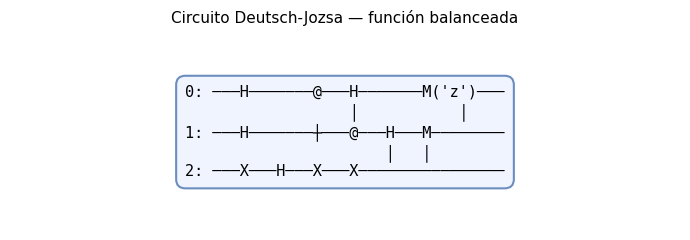

In [4]:
import matplotlib.pyplot as plt

diagrama = circuit_bal.to_text_diagram()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=11,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Circuito Deutsch-Jozsa — función balanceada', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

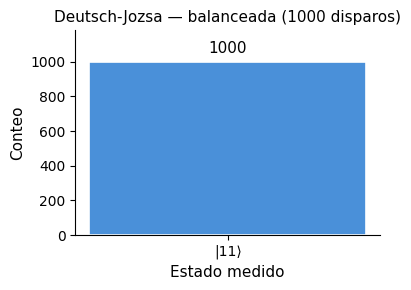

In [5]:
from qml_santanu.common.plot_utils import plot_counts

# Convertir resultado entero a binario para legibilidad
conteos_bal = {
    format(k, f'0{n}b'): v
    for k, v in result_bal.histogram(key='z').items()
}
plot_counts(conteos_bal, title='Deutsch-Jozsa — balanceada')

**Interpretación:** todas las mediciones dan $|11\rangle$. El estado $|00\rangle$ **nunca aparece** → la función es **balanceada**.

---
## Caso 2: función constante $f(x) = 0$

**Predicción:** sin oracle (identidad), la interferencia es completamente constructiva en $|00\rangle$.  
Todas las mediciones darán $|00\rangle$ (entero 0 en Cirq), confirmando que la función es constante.

In [6]:
circuit_const, result_const, n = deutsch_jozsa(domain_size=4,
                                                func_type_to_simulate='constant',
                                                copies=1000)
print(circuit_const)

0: ───H───H───M('z')───
              │
1: ───H───H───M────────

2: ───X───H────────────


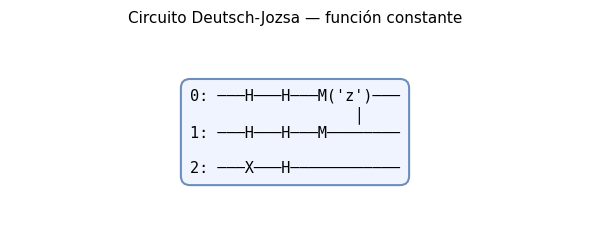

In [7]:
diagrama = circuit_const.to_text_diagram()

fig, ax = plt.subplots(figsize=(6, 2.5))
ax.text(
    0.5, 0.5, diagrama,
    fontfamily='monospace', fontsize=11,
    ha='center', va='center',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#6c8ebf', linewidth=1.5),
)
ax.axis('off')
ax.set_title('Circuito Deutsch-Jozsa — función constante', fontsize=11, pad=8)
plt.tight_layout()
plt.show()

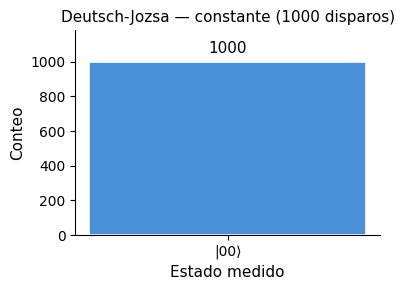

In [8]:
conteos_const = {
    format(k, f'0{n}b'): v
    for k, v in result_const.histogram(key='z').items()
}
plot_counts(conteos_const, title='Deutsch-Jozsa — constante')

**Interpretación:** todas las mediciones dan $|00\rangle$. El estado $|00\rangle$ **aparece siempre** → la función es **constante**.

---
## Resumen: regla de decisión

| Resultado de la medición | Conclusión |
|:---:|:---:|
| Siempre $\|00\rangle$ | Función **constante** |
| Nunca $\|00\rangle$ | Función **balanceada** |

Con una sola ejecución del circuito cuántico se obtiene la respuesta determinista, frente a las $2^{n-1}+1$ consultas que requiere el algoritmo clásico en el peor caso.